In [17]:
import pandas as pd
import matplotlib.pyplot as plt

POGOH Open Data provides datasets of user data per month. User data from 2023 was analyzed for this project.

In [18]:
january = pd.read_excel("january-2023.xlsx")
february = pd.read_excel("february-2023.xlsx")
march = pd.read_excel("march-2023.xlsx")
april = pd.read_excel("apr-2023.xlsx")
may = pd.read_excel("may-2023.xlsx")
june = pd.read_excel("june-2023.xlsx")
july = pd.read_excel("july-2023.xlsx")
august = pd.read_excel("august-2023.xlsx")
september = pd.read_excel("september-2023.xlsx")
october = pd.read_excel("october-2023.xlsx")
november = pd.read_excel("november-2023.xlsx")
december = pd.read_excel("december-2023.xlsx")

In [19]:
january

,Closed Status,Duration,Start Station Id,Start Date,Start Station Name,End Date,End Station Id,End Station Name,Rider Type
0,NORMAL,288,29,2023-01-31 23:49:31,Forbes Ave & Schenley Dr,2023-01-31 23:54:19,20.0,Boulevard of the Allies & Parkview Ave,MEMBER
1,NORMAL,322,29,2023-01-31 23:43:11,Forbes Ave & Schenley Dr,2023-01-31 23:48:33,10.0,Zulema St & Coltart Ave,MEMBER
2,NORMAL,483,7,2023-01-31 22:43:12,Liberty Ave & Gross St,2023-01-31 22:51:15,12.0,O'Hara St and University Place,MEMBER
3,NORMAL,236,29,2023-01-31 22:14:57,Forbes Ave & Schenley Dr,2023-01-31 22:18:53,10.0,Zulema St & Coltart Ave,MEMBER
4,NORMAL,550,12,2023-01-31 22:10:09,O'Hara St and University Place,2023-01-31 22:19:19,15.0,Ivy St & Walnut St,MEMBER
...,...,...,...,...,...,...,...,...,...
3824,NORMAL,1790,21,2023-01-01 00:39:18,Liberty Ave & Stanwix St,2023-01-01 01:09:08,24.0,Penn Ave & 33rd St,MEMBER
3825,NORMAL,1471,19,2023-01-01 00:23:14,42nd St & Butler St,2023-01-01 00:47:45,15.0,Ivy St & Walnut St,CASUAL
3826,NORMAL,5768,6,2023-01-01 00:21:41,10th St & Penn Ave,2023-01-01 01:57:49,4.0,Burns White Center at 3 Crossings,MEMBER
3827,GRACE_PERIOD,27,6,2023-01-01 00:20:31,10th St & Penn Ave,2023-01-01 00:20:58,6.0,10th St & Penn Ave,MEMBER


Since there are separate files for each month, I will combine them to get a cumulative dataset for the entire year.

In [20]:
months = [january, february, march, april, may, june, july, august, september, october, november, december]

In [21]:
combined = pd.concat(months)

In [22]:
combined

,Closed Status,Duration,Start Station Id,Start Date,Start Station Name,End Date,End Station Id,End Station Name,Rider Type
0,NORMAL,288,29,2023-01-31 23:49:31,Forbes Ave & Schenley Dr,2023-01-31 23:54:19,20.0,Boulevard of the Allies & Parkview Ave,MEMBER
1,NORMAL,322,29,2023-01-31 23:43:11,Forbes Ave & Schenley Dr,2023-01-31 23:48:33,10.0,Zulema St & Coltart Ave,MEMBER
2,NORMAL,483,7,2023-01-31 22:43:12,Liberty Ave & Gross St,2023-01-31 22:51:15,12.0,O'Hara St and University Place,MEMBER
3,NORMAL,236,29,2023-01-31 22:14:57,Forbes Ave & Schenley Dr,2023-01-31 22:18:53,10.0,Zulema St & Coltart Ave,MEMBER
4,NORMAL,550,12,2023-01-31 22:10:09,O'Hara St and University Place,2023-01-31 22:19:19,15.0,Ivy St & Walnut St,MEMBER
...,...,...,...,...,...,...,...,...,...
16136,NORMAL,605,51,2023-12-01 00:05:07,Coltart Ave & Forbes Ave,2023-12-01 00:15:12,51.0,Coltart Ave & Forbes Ave,MEMBER
16137,NORMAL,1271,50,2023-12-01 00:04:56,Atwood St & Bates St,2023-12-01 00:26:07,13.0,S Bouquet Ave & Sennott St,MEMBER
16138,NORMAL,1302,50,2023-12-01 00:04:24,Atwood St & Bates St,2023-12-01 00:26:06,13.0,S Bouquet Ave & Sennott St,MEMBER
16139,NORMAL,317,48,2023-12-01 00:01:21,S Millvale Ave & Centre Ave,2023-12-01 00:06:38,13.0,S Bouquet Ave & Sennott St,MEMBER


In [23]:
combined.dtypes

Closed Status          object
Duration                int64
Start Station Id        int64
Start Date             object
Start Station Name     object
End Date               object
End Station Id        float64
End Station Name       object
Rider Type             object
dtype: object

In [24]:
combined.describe()

,Duration,Start Station Id,End Station Id
count,2.112460e+05,211246.000000,211106.000000
mean,1.167303e+03,25.332697,25.058014
std,8.246505e+03,13.918654,13.928231
min,0.000000e+00,1.000000,1.000000
25%,2.520000e+02,13.000000,13.000000
50%,4.470000e+02,23.000000,23.000000
75%,9.800000e+02,34.000000,34.000000
max,1.969581e+06,62.000000,62.000000


To organize the values, I will add another column to add months to each row. The start and end date columns contain both the date and the timestamp, so adding months will make the data a lot clearer.

In [25]:
combined["Start Date"] = pd.to_datetime(combined["Start Date"])
combined["End Date"] = pd.to_datetime(combined["End Date"])

In [26]:
def get_month(date):
    if date.month == 1:
        return "January"
    elif date.month == 2:
        return "February"
    elif date.month == 3:
        return "March"
    elif date.month == 4:
        return "April"
    elif date.month == 5:
        return "May"
    elif date.month == 6:
        return "June"
    elif date.month == 7:
        return "July"
    elif date.month == 8:
        return "August"
    elif date.month == 9:
        return "September"
    elif date.month == 10:
        return "October"
    elif date.month == 11:
        return "November"
    elif date.month == 12:
        return "December"

This function will return the month of each value depending on what the month value in the datetime format corresponds to.

In [27]:
combined["Month"] = combined["Start Date"].apply(get_month)

In [28]:
combined

,Closed Status,Duration,Start Station Id,Start Date,Start Station Name,End Date,End Station Id,End Station Name,Rider Type,Month
0,NORMAL,288,29,2023-01-31 23:49:31,Forbes Ave & Schenley Dr,2023-01-31 23:54:19,20.0,Boulevard of the Allies & Parkview Ave,MEMBER,January
1,NORMAL,322,29,2023-01-31 23:43:11,Forbes Ave & Schenley Dr,2023-01-31 23:48:33,10.0,Zulema St & Coltart Ave,MEMBER,January
2,NORMAL,483,7,2023-01-31 22:43:12,Liberty Ave & Gross St,2023-01-31 22:51:15,12.0,O'Hara St and University Place,MEMBER,January
3,NORMAL,236,29,2023-01-31 22:14:57,Forbes Ave & Schenley Dr,2023-01-31 22:18:53,10.0,Zulema St & Coltart Ave,MEMBER,January
4,NORMAL,550,12,2023-01-31 22:10:09,O'Hara St and University Place,2023-01-31 22:19:19,15.0,Ivy St & Walnut St,MEMBER,January
...,...,...,...,...,...,...,...,...,...,...
16136,NORMAL,605,51,2023-12-01 00:05:07,Coltart Ave & Forbes Ave,2023-12-01 00:15:12,51.0,Coltart Ave & Forbes Ave,MEMBER,December
16137,NORMAL,1271,50,2023-12-01 00:04:56,Atwood St & Bates St,2023-12-01 00:26:07,13.0,S Bouquet Ave & Sennott St,MEMBER,December
16138,NORMAL,1302,50,2023-12-01 00:04:24,Atwood St & Bates St,2023-12-01 00:26:06,13.0,S Bouquet Ave & Sennott St,MEMBER,December
16139,NORMAL,317,48,2023-12-01 00:01:21,S Millvale Ave & Centre Ave,2023-12-01 00:06:38,13.0,S Bouquet Ave & Sennott St,MEMBER,December


In [29]:
combined.dtypes

Closed Status                 object
Duration                       int64
Start Station Id               int64
Start Date            datetime64[ns]
Start Station Name            object
End Date              datetime64[ns]
End Station Id               float64
End Station Name              object
Rider Type                    object
Month                         object
dtype: object

In [30]:
combined.isna().sum()

Closed Status           0
Duration                0
Start Station Id        0
Start Date              0
Start Station Name      0
End Date                0
End Station Id        140
End Station Name      135
Rider Type              0
Month                   0
dtype: int64

For the most part, POGOH has data on where riders may start, but not necessarily where they finish. This could account for people who may not indicate this in the bikeshare app.

Text(0.5, 1.0, 'Number of POGOH Rides Per Month in 2023')

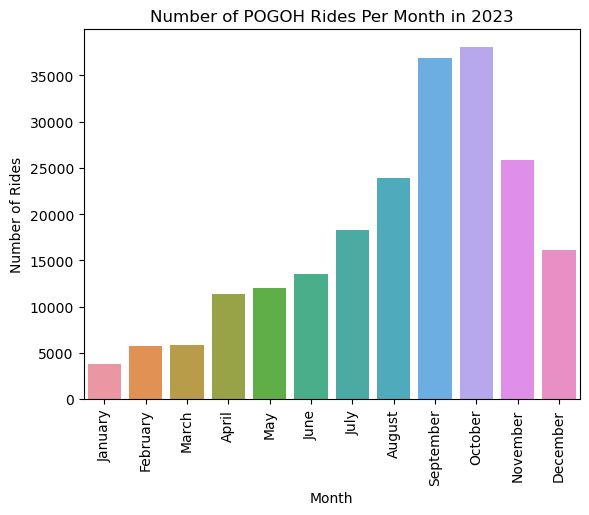

In [44]:
month_order = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]

import seaborn as sns

sns.countplot(x="Month", data=combined, order = month_order)
plt.xticks(rotation = 90)
plt.ylabel("Number of Rides")
plt.xlabel("Month")
plt.title("Number of POGOH Rides Per Month in 2023")

POGOH bikes are mostly utilized in August, September, October, and November. This timeframe typically marks the beginning of fall semester for the universities in the Pittsburgh area.

Text(0.5, 1.0, 'Total Duration of POGOH Rides Per Month in 2023')

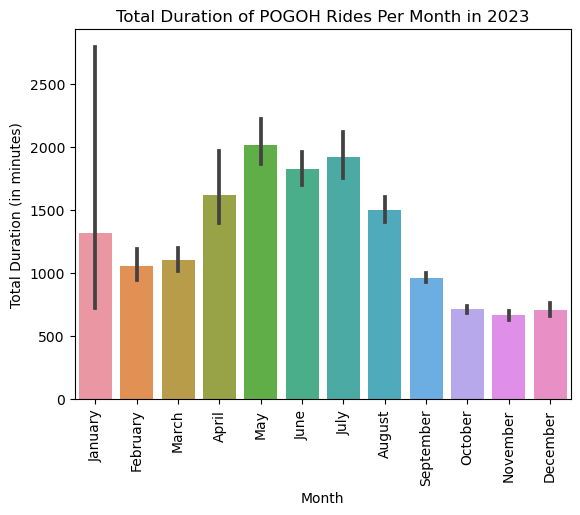

In [57]:
sns.barplot(combined, x="Month", y="Duration", order = month_order)
plt.xticks(rotation = 90)
plt.ylabel("Total Duration (in minutes)")
plt.xlabel("Month")
plt.title("Total Duration of POGOH Rides Per Month in 2023")

People tend to go on longer rides during the summer months.

In [80]:
combined.groupby(["Start Station Name"]).agg({"Rider Type":"count"}).sort_values("Rider Type", ascending=False)


,Rider Type
Start Station Name,
S Bouquet Ave & Sennott St,19138
Boulevard of the Allies & Parkview Ave,14927
Forbes Ave & Schenley Dr,12217
N Dithridge St & Centre Ave,12134
O'Hara St and University Place,11170
...,...
N Braddock Ave & Hamilton Ave,80
Wilkinsburg Park & Ride,76
Forbes Ave & Grant St,53


In [81]:
combined.groupby(["End Station Name"]).agg({"Rider Type":"count"}).sort_values("Rider Type", ascending=False)

,Rider Type
End Station Name,
S Bouquet Ave & Sennott St,19744
Boulevard of the Allies & Parkview Ave,14435
Forbes Ave & Schenley Dr,13148
O'Hara St and University Place,11691
N Dithridge St & Centre Ave,10614
...,...
N Braddock Ave & Hamilton Ave,89
Eliza St & Lytle St,79
Forbes Ave & Grant St,53
